<a href="https://colab.research.google.com/github/ulya1202/Data-science-projects/blob/main/LaCiPweek5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Life After Code in Place 2026 - Week 5 July 28, 2026
# Intro to Data Science


You may make copies of this and experiment on you own with data that is relevant to you. ***You are encouraged to!***

To make a copy of a Google CoLab get the URL, paste it into a browser, then click "File" -> "Save a copy in Drive". Then you have you own copy, you can optionally rename it with "File" -> "Rename". Remember to click the "Share" button and choose who to share it with before you give out the URL for your CoLab.

Or, you can click "File" -> "Download" -> "Download .ipynb"


**What is Google Colab?**: A free, cloud-based service to write and execute Python code in a web browser. A popular tool for machine learning and data analysis / data science.

**NOTE**: to make a copy of a Google CoLab get the URL, paste it into a browser, then click "File" -> "Save a copy in Drive". Then you have you own copy, you can optionally rename it. Remember to click the "Share" button and choose who to share it with before you give out the URL for your CoLab.

Last week LaCiPweek4 introduced numpy, pandas, and matplotlib. There is also an "Intro to Data Science" event recording in CIP6 on May 14, 2026 that might be interesting if you want more after today, it scratches the surface of Machine Learning at the end.

This shows how you can do some Data Science, data analysis and data manipulation, without being a Python expert, mathematician or statistician.

***First: Import some key Python libraries that are heavily used for Data Science:***


In [ ]:
# Python has libraries we can import to provide many different capabilities
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

**numpy** (Numerical Python) is an open-source Python library designed to handle large, multi-dimensional lists / arrays of numerical data, and perform mathematical operations.

**pandas** is a Python library used for data analysis and manipulation. pandas simplifies tasks such as data cleaning, transformation, aggregation, filtering, and visualization. It provides data structures including DataFrame.

**matplotlib.pyplot** is used for creating programmable static, animated, and interactive visualizations and plotting in Python. It is a state-based interface, meaning that it keeps track of the current figure and axes, and plotting functions are directed to these.

# LaCiP - Introduction to Data Science with World Happiness Data

We'll use a real CSV dataset to explore questions about happiness around the world.

We will use:

- **pandas** to load and analyze the data
- **NumPy** through pandas operations
- **Matplotlib** to create graphs

The goal is not just to run code. The goal is to use data to ask and answer interesting questions.

## Questions We Will Explore

- Which countries have the highest happiness scores?
- Which countries have the lowest happiness scores?
- How does happiness vary by region?
- Is economic strength related to happiness?
- Is health related to happiness?
- Is freedom related to happiness?
- Which variables are most strongly associated with happiness?

You can later customize the notebook to explore your own country or region.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_URL = "https://raw.githubusercontent.com/PhilippeCodes/World-Happiness-Report-Data-Analysis/master/World%20Happiness%20Report.csv"
happiness = pd.read_csv(DATA_URL)
happiness.head(7) # show first 7

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe
5,Netherlands,6,7.377,1.503945,1.428939,0.810696,0.585384,0.470490,0.282662,2.294804,93.8,Western Europe
6,Canada,7,7.316,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264,90.5,North America


In [ ]:
print("Rows and columns:", happiness.shape)

Rows and columns: (153, 12)


In [ ]:
happiness.columns   # display all of the column names

Index(['Country', 'Happiness Rank', 'Happiness Score', 'Economy', 'Family',
       'Health', 'Freedom', 'Generosity', 'Corruption', 'Dystopia',
       'Job Satisfaction', 'Region'],
      dtype='object')

In [ ]:
happiness.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Country           153 non-null    object 
 1   Happiness Rank    153 non-null    int64  
 2   Happiness Score   153 non-null    float64
 3   Economy           153 non-null    float64
 4   Family            153 non-null    float64
 5   Health            153 non-null    float64
 6   Freedom           153 non-null    float64
 7   Generosity        153 non-null    float64
 8   Corruption        153 non-null    float64
 9   Dystopia          153 non-null    float64
 10  Job Satisfaction  151 non-null    float64
 11  Region            153 non-null    object 
dtypes: float64(9), int64(1), object(2)
memory usage: 14.5+ KB


## What Can `info()` Tell Us?

`info()` shows:

- the column names
- the number of non-missing values
- the data type of each column
- the approximate memory used

Notice that `Job Satisfaction` has a small number of missing values.

In [ ]:
happiness.isna().sum()   # shows count of missing values in each column.

,0
Country,0
Happiness Rank,0
Happiness Score,0
Economy,0
Family,0
Health,0
Freedom,0
Generosity,0
Corruption,0
Dystopia,0


## First Data Science Habit

Before analyzing a dataset, always ask:

1. What does each row represent?
2. What does each column represent?
3. Are any values missing?
4. Are the data types reasonable?
5. Does the dataset appear to have loaded correctly?

In [ ]:
happiness.describe()     # display summary statistics for the numeric columns

,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,151.000000
mean,78.169935,5.349281,0.982433,1.186630,0.550117,0.408489,0.245324,0.123179,1.853072,75.209934
std,45.008741,1.134997,0.421901,0.288441,0.237769,0.150744,0.134395,0.102133,0.499490,12.962365
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914,44.400000
25%,40.000000,4.497000,0.659517,1.041990,0.364509,0.300741,0.153075,0.057070,1.597970,68.950000
50%,78.000000,5.279000,1.064578,1.251826,0.606042,0.437454,0.231503,0.089848,1.832910,78.100000
75%,117.000000,6.098000,1.315175,1.416404,0.719217,0.518631,0.322228,0.153066,2.150801,85.100000
max,155.000000,7.537000,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485,95.100000


## Understanding `describe()`

For each numeric column, pandas displays:

- `count`
- `mean`
- `std`
- `min`
- quartiles
- `max`

This is a quick way to understand the range and typical values in the data.

In [ ]:
# display the 10 countries with the highest happiness scores, with only specified columns
happiest_10 = happiness.sort_values(
    "Happiness Score",
    ascending=False
).head(10)

happiest_10[["Country", "Region", "Happiness Score"]]

,Country,Region,Happiness Score
0,Norway,Western Europe,7.537
1,Denmark,Western Europe,7.522
2,Iceland,Western Europe,7.504
3,Switzerland,Western Europe,7.494
4,Finland,Western Europe,7.469
5,Netherlands,Western Europe,7.377
6,Canada,North America,7.316
7,New Zealand,Asia-Pacific,7.314
8,Sweden,Western Europe,7.284
9,Australia,Asia-Pacific,7.284


In [ ]:
# display the 10 countries with the lowest happiness scores, with only specified columns
lowest_10 = happiness.sort_values(
    "Happiness Score",
    ascending=True
).head(10)

lowest_10[["Country", "Region", "Happiness Score", "Job Satisfaction"]]

,Country,Region,Happiness Score,Job Satisfaction
152,Central African Republic,Africa,2.693,70.4
151,Burundi,Africa,2.905,54.3
150,Tanzania,Africa,3.349,57.8
149,Syria,Asia-Pacific,3.462,62.7
148,Rwanda,Africa,3.471,51.7
147,Togo,Africa,3.495,44.8
146,Guinea,Africa,3.507,55.1
145,Liberia,Africa,3.533,56.6
144,South Sudan,Africa,3.591,NaN
143,Yemen,Asia-Pacific,3.593,58.9


## Find a Country

Change the value of `country_name` to explore your own country.

Be careful to match the spelling and case used in the dataset.

In [ ]:
country_name = "Canada"

happiness[happiness["Country"] == country_name]

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
6,Canada,7,7.316,1.479204,1.481349,0.834558,0.611101,0.43554,0.287372,2.187264,90.5,North America


### Optional Extension

Try changing `country_name` to:

- your own country
- a neighboring country
- a country you have visited
- a country you would like to visit

In [ ]:
# calculate basic statistics for Happiness Score
scores = happiness["Happiness Score"]

print("Mean:", scores.mean())
print("Median:", scores.median())
print("Minimum:", scores.min())
print("Maximum:", scores.max())

Mean: 5.349281046130718
Median: 5.278999805
Minimum: 2.693000078
Maximum: 7.537000179


## Mean and Median

The **mean** is the arithmetic average.

The **median** is the middle value after the data is sorted.

If the mean and median are close, the distribution may be fairly balanced.

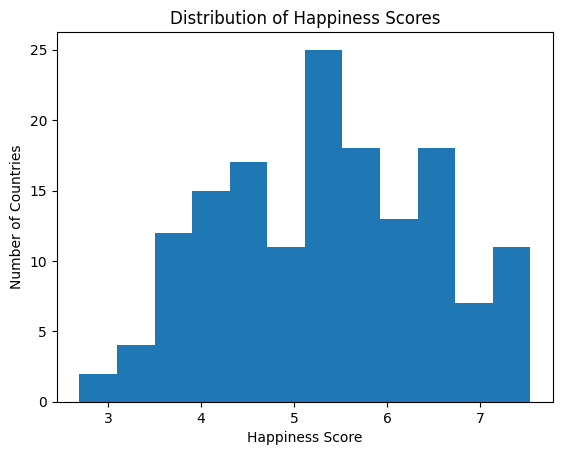

In [ ]:
# create a histogram of happiness scores
plt.hist(happiness["Happiness Score"], bins=12)

plt.xlabel("Happiness Score")
plt.ylabel("Number of Countries")
plt.title("Distribution of Happiness Scores")

plt.show()

## Reading the Histogram

A histogram groups numeric values into ranges.

Ask:

- Where are most countries concentrated?
- Are very high scores common?
- Are very low scores common?
- Does the distribution look balanced or skewed?

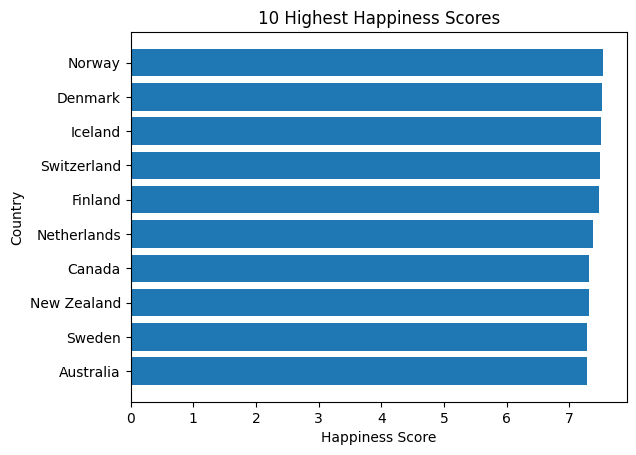

In [ ]:
# create a horizontal bar chart of the 10 happiest countries
top_10_plot = happiest_10.sort_values("Happiness Score")

plt.barh(
    top_10_plot["Country"],
    top_10_plot["Happiness Score"]
)

plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.title("10 Highest Happiness Scores")

plt.show()

## Grouping by Region

Instead of comparing individual countries, we can compare regional averages.

`groupby()` is one of the most useful operations in pandas.

In [ ]:
# calculate average happiness by region
regional_happiness = (
    happiness.groupby("Region")["Happiness Score"]
    .mean()
    .sort_values(ascending=False)
)

regional_happiness

,Happiness Score
Region,
North America,7.154500
Western Europe,6.880474
Latin America,5.957818
Eastern Europe,5.513091
Asia-Pacific,5.358326
Africa,4.239500
Europe,4.096000


In [ ]:
# Data  shows Region "Europe" has lowest score, let's see what countries are in "Europe"
# (not in "Western Europe" or "Eastern Europe")
europe_happiness = happiness[happiness["Region"] == "Europe"]
print(europe_happiness)

     Country  Happiness Rank  Happiness Score   Economy    Family    Health  \
129  Ukraine             132            4.096  0.894652  1.394538  0.575904   

      Freedom  Generosity  Corruption  Dystopia  Job Satisfaction  Region  
129  0.122975    0.270061    0.023029  0.814382              72.3  Europe  


In [ ]:
# what is overall European happiness?
all_europe_happiness = happiness[
    (happiness["Region"] == "Western Europe") |
    (happiness["Region"] == "Europe") |
    (happiness["Region"] == "Eastern Europe")
]
print("Overall European happiness:", all_europe_happiness["Happiness Score"].mean())

Overall European happiness: 6.097928580833334


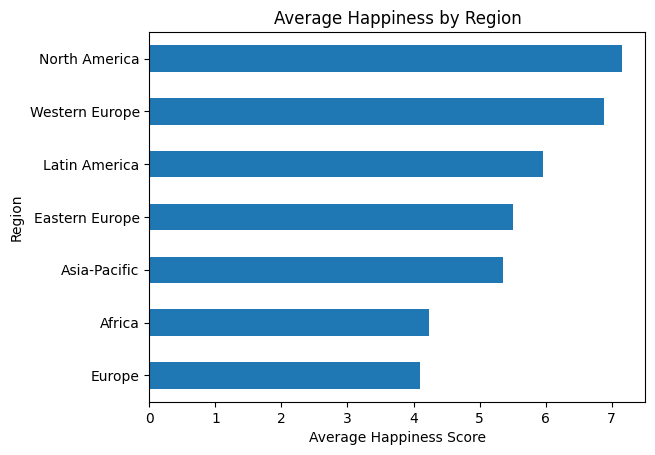

In [ ]:
# graph average happiness by region
regional_happiness.sort_values().plot(kind="barh")

plt.xlabel("Average Happiness Score")
plt.ylabel("Region")
plt.title("Average Happiness by Region")

plt.show()

## Important Interpretation Reminder

A regional average does not describe every person or every country in that region.

Averages summarize data, but they also hide differences.

Data science requires both calculation and careful interpretation.

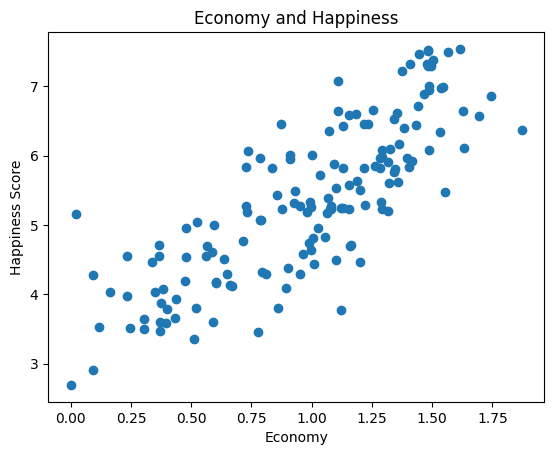

In [ ]:
# graph Economy versus Happiness Score
plt.scatter(
    happiness["Economy"],
    happiness["Happiness Score"]
)

plt.xlabel("Economy")
plt.ylabel("Happiness Score")
plt.title("Economy and Happiness")

plt.show()

## Does Money Buy Happiness?

The graph may show a positive relationship:

Countries with stronger economic scores often have higher happiness scores.

However:

> Correlation does not prove causation.

Economic strength may be related to happiness, but this graph alone cannot prove that one causes the other.

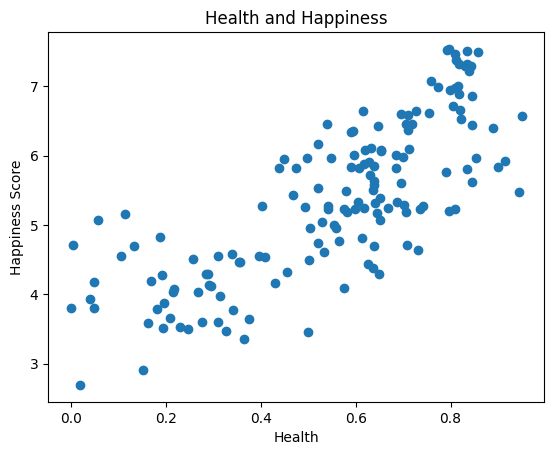

In [ ]:
# graph Health versus Happiness Score
plt.scatter(
    happiness["Health"],
    happiness["Happiness Score"]
)

plt.xlabel("Health")
plt.ylabel("Happiness Score")
plt.title("Health and Happiness")

plt.show()

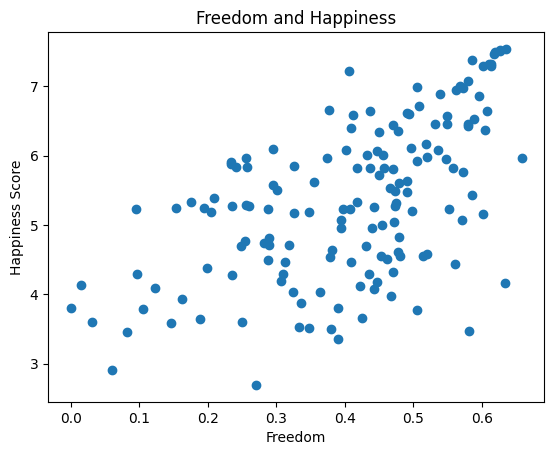

In [ ]:
# Freedom versus Happiness Score
plt.scatter(
    happiness["Freedom"],
    happiness["Happiness Score"]
)

plt.xlabel("Freedom")
plt.ylabel("Happiness Score")
plt.title("Freedom and Happiness")

plt.show()

## Compare the Scatterplots

Ask yourself:

- Which relationship looks strongest?
- Which graph has points clustered closest to an upward trend?
- Are there unusual countries that do not follow the general pattern?
- What additional information would help explain the results?

In [ ]:
# calculate correlations among the numeric columns
correlations = happiness.corr(numeric_only=True)

correlations.round(2)

,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction
Happiness Rank,1.00,-0.99,-0.81,-0.74,-0.78,-0.56,-0.14,-0.41,-0.48,-0.81
Happiness Score,-0.99,1.00,0.81,0.75,0.78,0.58,0.16,0.44,0.47,0.81
Economy,-0.81,0.81,1.00,0.69,0.84,0.38,-0.02,0.36,0.02,0.70
Family,-0.74,0.75,0.69,1.00,0.61,0.43,0.05,0.23,0.07,0.62
Health,-0.78,0.78,0.84,0.61,1.00,0.35,0.07,0.29,0.05,0.70
Freedom,-0.56,0.58,0.38,0.43,0.35,1.00,0.31,0.50,0.09,0.50
Generosity,-0.14,0.16,-0.02,0.05,0.07,0.31,1.00,0.29,-0.10,0.22
Corruption,-0.41,0.44,0.36,0.23,0.29,0.50,0.29,1.00,-0.02,0.34
Dystopia,-0.48,0.47,0.02,0.07,0.05,0.09,-0.10,-0.02,1.00,0.28
Job Satisfaction,-0.81,0.81,0.70,0.62,0.70,0.50,0.22,0.34,0.28,1.00


## Understanding Correlation

Correlation ranges from `-1` to `1`.

- Close to `1`: strong positive relationship
- Close to `-1`: strong negative relationship
- Close to `0`: weak linear relationship

Correlation describes association, not causation.

In [ ]:
# see which variables are most strongly correlated with Happiness Score
happiness_correlations = (
    correlations["Happiness Score"]
    .drop("Happiness Score")
    .sort_values(ascending=False)
)

happiness_correlations

,Happiness Score
Job Satisfaction,0.812873
Economy,0.811194
Health,0.780496
Family,0.753815
Freedom,0.576027
Dystopia,0.474300
Corruption,0.435854
Generosity,0.160010
Happiness Rank,-0.992782


## A Data Science Question

Which variables appear most strongly associated with happiness?

Remember:

- The variables may overlap with one another.
- A correlation may be influenced by other variables.
- Country-level averages do not describe every person.
- This is an exploratory analysis, not proof of cause and effect.

In [ ]:
# compare selected countries, optionally change the names to customize the analysis
selected_countries = [
    "Japan",
    "Brazil",
    "India",
    "Kenya",
    "Germany"
]

comparison = happiness[
    happiness["Country"].isin(selected_countries)
][
    [
        "Country",
        "Happiness Score",
        "Economy",
        "Health",
        "Freedom",
        "Generosity"
    ]
]

comparison.sort_values("Happiness Score", ascending=False)

,Country,Happiness Score,Economy,Health,Freedom,Generosity
15,Germany,6.951,1.487923,0.798951,0.562511,0.336269
21,Brazil,6.635,1.107353,0.616552,0.437454,0.162350
49,Japan,5.920,1.416915,0.913476,0.505626,0.120573
109,Kenya,4.553,0.560479,0.309988,0.452764,0.444860
119,India,4.315,0.792221,0.455428,0.469987,0.231538


### Optional Extension

Replace the country names with countries selected by the class.

You could compare:

- countries represented by students
- neighboring countries
- countries from the same region
- countries with similar economic scores

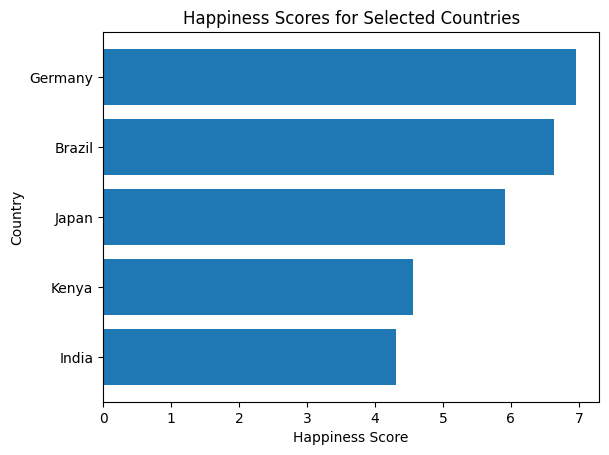

In [ ]:
# compare the selected countries in a bar chart
comparison_plot = comparison.sort_values("Happiness Score")

plt.barh(
    comparison_plot["Country"],
    comparison_plot["Happiness Score"]
)

plt.xlabel("Happiness Score")
plt.ylabel("Country")
plt.title("Happiness Scores for Selected Countries")

plt.show()

## Optional Extensions for students to do on your own time

Students can make a personal copy of this Colab notebook and explore further.

Possible extensions:

- Change the selected countries.
- Find the top 10 countries for `Health`.
- Find the top 10 countries for `Freedom`.
- Compare average `Economy` by region.
- Plot `Generosity` versus `Happiness Score`.
- Explore `Job Satisfaction`.
- Investigate countries that do not follow the general trends.
- Change graph titles, labels, or figure sizes.

## Questions you can later to think about on your own

1. Which result surprised you most?
2. Does a high economic score guarantee a high happiness score?
3. Which variables seem most closely related to happiness?
4. What important information is missing from this dataset?
5. What are the risks of ranking entire countries using one number?

## Summary

In this notebook, we used data science to explore happiness around the world.

We used:

- `pd.read_csv()` to load CSV data
- `head()`, `info()`, and `describe()` to inspect data
- filtering to find countries
- `sort_values()` to rank data
- `groupby()` to compare regions
- Matplotlib to create graphs
- correlation to examine relationships

Most importantly, we used Python to ask questions about the world.

That is the heart of data science.

# Data Science Classification


<table>
<tr>
<td>

Iris Setosa

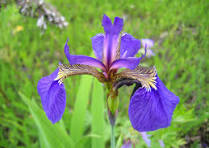

</td>
<td>

Iris Versica

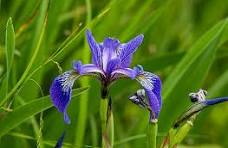

</td>
<td>

Iris Virginica

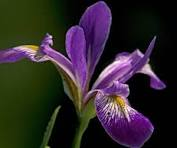

</tr>
</td>
</table>

We will work with a type of prediction called **classification**.<br><br>
We use the classic Canadian iris dataset, which is a dataset used in Data Science and Machine Learning. It contains data of 3 different species of iris flowers observed in Quebec in 1936.

**Key libraries used in Data Science and ML:**<br>
**numpy**: Scientific computing library providing high-performance, multi-dimensional array objects and the math tools to manipulate them.

**pandas**: Powerful data analysis library built on top of numpy that contains the DataFrame, a 2D table structure (like a database or an Excel sheet) used for cleaning, filtering, and manipulating data.

**matplotlib.pyplot**: A sub-module of the Matplotlib library that provides a MATLAB-like static, animated, and interactive visualizations like line plots and scatter charts.

The following 10 lines of code read in the dataset, print the numbers of rows and columns, and display the first 5 rows.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/DeAnzaDataScience/CIS11/refs/heads/main/datasets_exercises/iris.csv"
iris = pd.read_csv(url)   # get DataFrame representing whole data set
rows, columns = iris.shape
print("Number of rows:", rows)
print("Number of columns:", columns)
print("First 5 rows:")
iris.tail()               # show last 5 rows of DataFrame

Number of rows: 150
Number of columns: 5
First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Here we display the scatterplot of `petal_length` and `petal_width`.

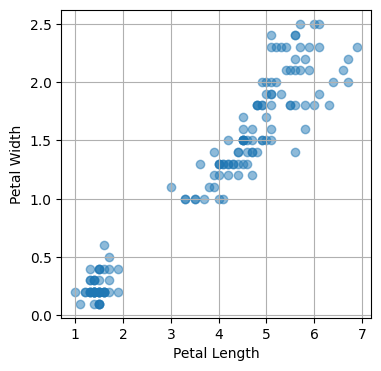

In [ ]:
plt.figure(figsize=(4,4))
plt.scatter(iris['petal_length'], iris['petal_width'], alpha=0.5)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.grid()
plt.show()

There seems to be some association between the petal lengths and widths. The larger the length, the larger the width.<br>
However, we would like to see if the lengths and widths are different between the 3 species. Separate the data into 3 groups, and plot the petal lengths vs petal widths for each group.

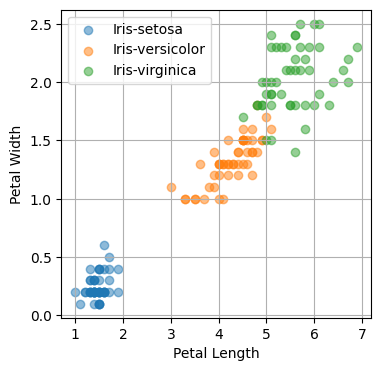

In [ ]:
plt.figure(figsize=(4,4))

groups = iris.groupby('species')

for name, group in groups:
    plt.scatter(group['petal_length'], group['petal_width'], alpha=0.5, label=name)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.grid()
plt.show()

It's more clear how to determine the type of iris if we know the length and width of the petal. The 'setosa' has the smallest sized petal, the 'versicolor' has a medium size petal, and the 'virginica' has the largest petal.

But the "border" between the 'versicolor' and the 'virginica' has significant overlap, we can only get so accurate using that.<br>

Below illustrates **classification**. Classification is a supervised learning task where an algorithm learns to assign a specific label or category to a piece of data based on its features.<br><br>
**Classification Core Elements**:<br>
**The Input (Features)**: The measurable traits of the object (e.g., Petal Length, Petal Width).

**The Output (Labels)**: The discrete categories you want to predict (e.g., Iris-setosa, Iris-versicolor, Iris-virginica).

**The Boundary**: The logic the model creates to "split" the groups in multi-dimensional space.<br><br>

**Binary Classification**: A "Yes/No" choice (e.g., Is this email Spam or Not Spam?).

**Multi-class Classification**: Choosing one from several options (e.g., Which of the three Iris species is this?).

In [ ]:
def classify_iris(row):
    # Rule 1: setosa is easily separated by length
    if row['petal_length'] < 2.5:
        return 'Iris-setosa'

    # Rule 2: Distinguish versicolor/virginica using Width (2nd dimension)
    if row['petal_width'] > 1.75:
        return 'Iris-virginica'
    else:
        return 'Iris-versicolor'

# Apply our manual "model"
iris['prediction'] = iris.apply(classify_iris, axis=1)

# Calculate Accuracy
accuracy = (iris['prediction'] == iris['species']).mean() * 100
print(f"Manual 2D Accuracy: {accuracy:.2f}%")

iris.tail(20)


Manual 2D Accuracy: 96.00%


,sepal_length,sepal_width,petal_length,petal_width,species,prediction
130,7.4,2.8,6.1,1.9,Iris-virginica,Iris-virginica
131,7.9,3.8,6.4,2.0,Iris-virginica,Iris-virginica
132,6.4,2.8,5.6,2.2,Iris-virginica,Iris-virginica
133,6.3,2.8,5.1,1.5,Iris-virginica,Iris-versicolor
134,6.1,2.6,5.6,1.4,Iris-virginica,Iris-versicolor
135,7.7,3.0,6.1,2.3,Iris-virginica,Iris-virginica
136,6.3,3.4,5.6,2.4,Iris-virginica,Iris-virginica
137,6.4,3.1,5.5,1.8,Iris-virginica,Iris-virginica
138,6.0,3.0,4.8,1.8,Iris-virginica,Iris-virginica
139,6.9,3.1,5.4,2.1,Iris-virginica,Iris-virginica


The **Seaborn** Python visualization library is used in both Data Science and Machine Learning. In Machine Learning, Seaborn is a diagnostic tool. You don't use it to train the model, but you use it to see if your model is working or if the features/attributes/columns you're using are bad.<br><br>
This tiny bit of code below shows many views of the data. We classified based on petal length vs. petal width. Arguably could've chosen petal width vs sepal width, or pedal width vs sepal length.

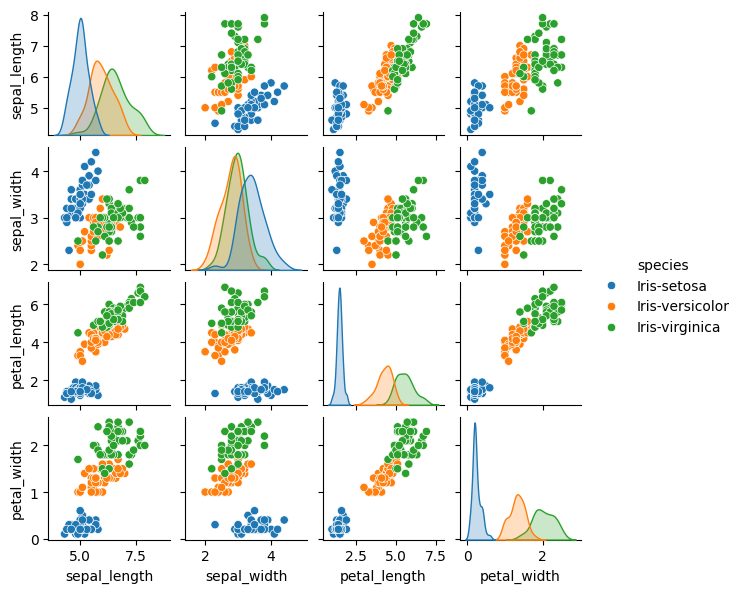

In [ ]:
import seaborn as sns
sns.pairplot(iris, hue='species', height=1.5);

##We were looking at Data Science, now let's look a bit at Machine Learning
The distinction between the two is a bit fuzzy actually


##**sklearn** is industry standard library for Machine Learning.

**scikit-learn** is official name of library, imported as sklearn, both terms used.

The entire design of **scikit-learn** is built around the Machine Learning Pipeline:

**Preprocessing**: Scaling and centering data so the computer can read and clean it.

**Modeling**: The actual algorithms (Random Forest, k-Nearest Neighbors, etc) that "learn" from the data.

**Validation**: Tools like train_test_split and accuracy_score to see how well the model works.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Setup 4D Features (X) and Target (y)
# We use: Sepal Length, Sepal Width, Petal Length, Petal Width
X = iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = iris['species']

# 2. Split the data
# 70% for training, 30% for testing to see how it handles "unseen" data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Initialize and Train the Model
# Random Forest is excellent for 4D data because it builds multiple "Decision Trees"
model = RandomForestClassifier(n_estimators=100)  # Create forest object, 100 trees
model.fit(X_train, y_train)        # Teach the forest, the training phase

# 4. Predict and Evaluate
y_pred = model.predict(X_test)     # The prediction phase
accuracy = accuracy_score(y_test, y_pred)

print(f"4D Random Forest Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

4D Random Forest Accuracy: 100.00%

Detailed Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



##Two of many Machine Learning Algorithms that learn from the data are:
**k-Nearest Neighbors (k-NN)**<br><br>To classify a new flower, the model looks at the $k$ closest data points (neighbors) in the 2D or 4D space. If the 5 closest neighbors are mostly Iris-versicolor, the new flower is labeled Iris-versicolor. Used in DS and ML.<br><br>

**Random Forest**<br><br>
It creates hundreds of different Decision Trees (like the manual if/else logic we wrote earlier), but each tree sees a slightly different version of the data. Every tree "votes" on the species, and the forest picks the winner.<br><br>
Random Forest handles 4D+ data effortlessly. It’s essentially collection of the manual if/else rules.<br><br>

**A Random Forest is an Ensemble Learning method.** Instead of relying on one single "smart" decision tree to make a prediction, it builds an entire forest of "weak" trees and lets them vote.<br><br>

**How Random Forest works (The Three "R's")**:<br>
**Random Sampling**: Each tree in the forest is trained on a random subset of the data (this is called Bagging).<br><br>

**Random Features**: When a tree decides how to split the data (e.g., "Is Petal Length > 2.5?"), it is only allowed to look at a random selection of the 4 features.<br><br>

**Result (Voting)**: To get the final answer, the forest takes a "Majority Vote". If 95 trees say Iris-versicolor and 5 say Iris-virginica, the model outputs Iris-versicolor.

<br>**SUMMARY**: Today we used Google CoLab and reviewed Python libraries **numpy**, **pandas** and **matplotlib.pyplot** to illustrate some nice capabilities for working with data in Python. We reviewed at some **Data Science** concepts with examples, and we took a small peek into some very basic **Machine Learning** using **scikit-learn**.
<br><br>

Here are some good places to find other publicly available data to analyze:<br>
https://www.kaggle.com/datasets <br>
https://archive.ics.uci.edu/ <br>
https://data.gov/ <br>
https://datasetsearch.research.google.com/ <br>
https://github.com/awesomedata/awesome-public-datasets <br>
https://www.who.int/data/gho <br>
https://data.un.org/ <br>
https://data.worldbank.org/ <br><br>


Kaggle has datasets and examples of notebooks using them. For example https://www.kaggle.com/code/mllion/goat-analysis    GOAT ANALYSIS, an Explorative Data Analysis that is dedicated to Lionel Messi.<br><br>
There is also https://www.kaggle.com/code/luismylo/messi-vs-ronaldo Messi vs. Ronaldo<br><br> There is also https://www.kaggle.com/code/mayurdushetwar/mbappe-vs-haaland  Mbappe vs Haaland

**REMINDER**: to make a copy of a Google CoLab get the URL, paste it into a browser, then click "File" -> "Save a copy in Drive". Then you have you own copy, you can optionally rename it with "File" -> "Rename". Remember to click the "Share" button and choose who to share it with before you give out the URL for your CoLab.

Or, you can click "File" -> "Download" -> "Download .ipynb"

Note that Data Science and Machine Learning and AI involve not just Python but statistics and probability as you get into them more.

Some good free resources among the many available for Data Science and Machine Learning include:<br><br>


Python Data Science Handbook: https://jakevdp.github.io/PythonDataScienceHandbook/index.html

Statistics:  https://onlinestatbook.com/2/introduction/descriptive.html

Stanford CS 109: Probability for Computer Scientists has some free resources https://web.stanford.edu/class/cs109/

An Introduction to Statistical Learning (with Python, do NOT look at R book) https://www.statlearning.com

Free UIUC online Data Science course (no certificate, etc, but good info): https://discovery.cs.illinois.edu/



